# **PRACTICE: Neural Language Model for Aggressiveness**

In this notebook, we present an example of how to use a GRU to classify tweets in the aggressive/non-aggressive task. The dataset comes from the **MEX-A3T: Fake News and Aggressiveness Analysis** competition (in spanish)

In [2]:
# Necessary libraries.
import numpy as np                                    # library for numerical operations.
import nltk                                           # library for text processing.
import matplotlib.pyplot as plt                       # for plotting.
import seaborn as sns                                 # for plotting.
import pandas as pd                                   # for data manipulation.
from collections import Counter                       # library for counting.
nltk.download('punkt', force = True)                  # download the necessary dataset.
nltk.download('punkt_tab', force = True)              # download the necessary dataset.
from tqdm.notebook import tqdm                        # library for progress bars.
import copy                                           # library for copying.
import torch                                          # library for tensor operations.
from torch import nn, optim                           # for neural networks.
from torch.utils.data import Dataset, DataLoader      # for creating mini-batches.
from typing import List, Tuple                        # for type hinting.
import time                                           # for timing.
from colorama import Fore, Style                      # library for colored text.
from torch.nn.utils.rnn import (pad_packed_sequence,  # for padding.
                                pack_padded_sequence) # for padding.
from sklearn.model_selection import train_test_split  # for splitting the dataset.
import torch.nn.functional as F                       # for activation functions.
from sklearn.metrics import f1_score                  # for evaluation.
np.random.seed(0)                                     # seed for reproducibility.
torch.manual_seed(0)                                  # seed for reproducibility.
torch.backends.cudnn.benchmark = False                # reproducibility.


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ezautorres/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/ezautorres/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


We have two datasets, one for training and one for validation, with their respective labels. We need to merge them to separate them into:
- Training set
- Validation set
- Test set.

Number of samples per class in the training data   : Counter({0: 2924, 1: 1181})
Number of samples per class in the validation data : Counter({0: 626, 1: 254})
Number of samples per class in the testing data    : Counter({0: 627, 1: 253})


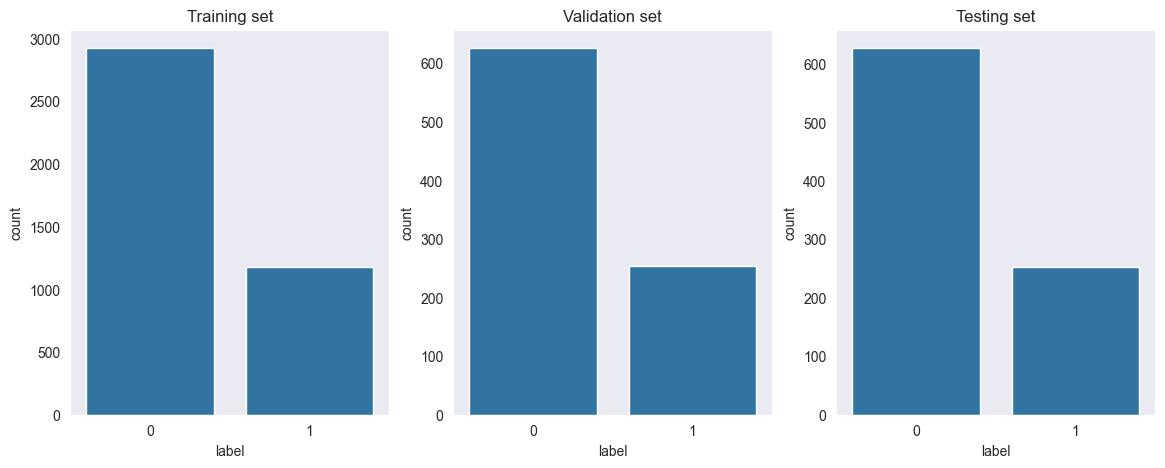

In [3]:
def get_text_from_file(path_corpus: str, path_labels: str) -> Tuple[List[str], List[int]]:
    """
    Read the text and labels from the files.

    Parameters
    ----------
    path_corpus : str
        Path to the file containing the text.
    path_labels : str
        Path to the file containing the labels.

    Returns
    -------
    tuple
        A tuple containing the text and the labels.
    """
    with open(path_corpus, 'r', encoding = 'utf-8') as f_corpus, open(path_labels, 'r', encoding = 'utf-8') as f_labels:
        data   = f_corpus.readlines()                 # Read the text line by line.
        labels = list(map(int, f_labels.readlines())) # Read the labels line by line.
    return data, labels

# Load the data.
data_tr, labels_tr   = get_text_from_file('./mex20_train.txt', './mex20_train_labels.txt') # Training data.
data_val, labels_val = get_text_from_file('./mex20_val.txt', './mex20_val_labels.txt')     # Validation data.

# Combine the training and validation data.
data_all = data_tr + data_val
labels_all = labels_tr + labels_val

# Split the data into training, validation, and testing sets. 70% training, 15% validation, and 15% testing.
data_train, data_temp, labels_train, labels_temp = train_test_split(
    data_all, labels_all, test_size = 0.3, random_state = 42, stratify = labels_all
)
data_val, data_test, labels_val, labels_test = train_test_split(
    data_temp, labels_temp, test_size = 0.5, random_state = 42, stratify = labels_temp
)
print("Number of samples per class in the training data   :", Counter(labels_train))
print("Number of samples per class in the validation data :", Counter(labels_val))
print("Number of samples per class in the testing data    :", Counter(labels_test))

# Visualize the data.
sns.set_style("dark")
fig, axs = plt.subplots(1, 3, figsize = (14,5))
sns.countplot(data = pd.DataFrame(labels_train, columns = ["label"]), x = "label", ax = axs[0])
sns.countplot(data = pd.DataFrame(labels_val, columns = ["label"]), x = "label", ax = axs[1])
sns.countplot(data = pd.DataFrame(labels_test, columns = ["label"]), x = "label", ax = axs[2])
axs[0].set_title("Training set")
axs[1].set_title("Validation set")
axs[2].set_title("Testing set")
plt.show()

## **AggressionDataset**

The PyTorch Dataset class allows for organized data management and simple interaction with the DataLoader object used to create and load batches of data.

In [11]:
len(train_dataset.emb_mat)

973267

In [15]:
train_dataset.vocab

{'de': 2,
 'que': 3,
 'la': 4,
 'a': 5,
 'y': 6,
 'el': 7,
 'no': 8,
 'en': 9,
 'me': 10,
 'to': 11,
 'es': 12,
 'replying': 13,
 'con': 14,
 'se': 15,
 'mi': 16,
 'un': 17,
 'lo': 18,
 'los': 19,
 'por': 20,
 'te': 21,
 'para': 22,
 'las': 23,
 'twitter': 24,
 'una': 25,
 'del': 26,
 'si': 27,
 'ya': 28,
 'como': 29,
 'yo': 30,
 'i': 31,
 'at': 32,
 'm': 33,
 'al': 34,
 'pero': 35,
 'q': 36,
 'tu': 37,
 'esta': 38,
 'todo': 39,
 'hoy': 40,
 'mas': 41,
 'in': 42,
 'pic': 43,
 'le': 44,
 'quiero': 45,
 'cuando': 46,
 'hay': 47,
 'o': 48,
 'mejor': 49,
 'tengo': 50,
 'vida': 51,
 'ahora': 52,
 'su': 53,
 'este': 54,
 'd': 55,
 'bien': 56,
 'ser': 57,
 'nada': 58,
 'voy': 59,
 'estoy': 60,
 'gracias': 61,
 'nos': 62,
 'ver': 63,
 'todos': 64,
 'eso': 65,
 'sin': 66,
 'siempre': 67,
 'muy': 68,
 'jajaja': 69,
 'son': 70,
 'ni': 71,
 'solo': 72,
 'porque': 73,
 'mis': 74,
 'casa': 75,
 'amor': 76,
 'tan': 77,
 'va': 78,
 'dios': 79,
 'san': 80,
 'hace': 81,
 'soy': 82,
 'feliz': 83,
 'tiene

In [4]:
class AggressionDataset(Dataset):
    def __init__(self, corpus: List[str], labels: List[int]):
        
        # Initialize the dataset.
        self.corpus = corpus
        self.labels = labels

        # Load the vocabulary and embeddings.
        self.vocab, self.emb_mat = AggressionDataset.load_vocab_embeddings()

    def __len__(self) -> int:
        """
        Return the number of samples in the dataset.
        """
        return len(self.corpus)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int, List[str]]:
        """
        Get the item at the specified index.

        Parameters
        ----------
        index : int
            The index of the item.

        Returns
        -------
        tuple
            A tuple containing the word ids, label, and words.
        """
        text = self.corpus[index]
        label = self.labels[index]
        words, word_ids = self.preprocessed_text(text)
        return word_ids, label, words

    def preprocessed_text(self, text: str) -> Tuple[List[str], List[int]]:
        """
        Preprocess the text.

        Parameters
        ----------
        text : str
            The text to be preprocessed.
        
        Returns
        -------
        tuple
            A tuple containing the words and word ids.
        """
        words = nltk.word_tokenize(text)
        word_ids = [self.vocab[word] if word in self.vocab.keys() else self.emb_mat.shape[0] - 1
                    for word in words]
        return words, word_ids
    
    @staticmethod
    def load_vocab_embeddings() -> Tuple[dict, np.ndarray]:
        """
        Load the vocabulary and pre-trained embeddings.

        Returns
        -------
        tuple
            A tuple containing the vocabulary and embeddings.
        """
        embeddings_list = []
        vocab = {}
        with open('word2vec_col.txt', 'r') as f:
            for i, line in enumerate(f):
                if i != 0:
                    values = line.split()
                    vocab[values[0]] = i + 1
                    vector = np.asarray(values[1:], dtype = "float32")
                    embeddings_list.append(vector)
        embeddings_list.insert(0, np.mean(np.vstack(embeddings_list), axis = 0)) # Mean vector for unk
        embeddings_list.insert(0, np.zeros(100))                                 # Padding vector
        vocab['pad'] = 0
        vocab['unk'] = 1
        emb_mat = np.vstack(embeddings_list)
        return vocab, emb_mat

    def get_weights(self) -> torch.Tensor:
        """
        Calculate class weights for imbalanced datasets. The higher weight the category has, the less samples it has.
        """
        cat_0 = self.labels.count(0)
        cat_1 = self.labels.count(1)
        maxi = max(cat_0, cat_1)
        return torch.tensor([maxi / cat_0, maxi / cat_1])

    @staticmethod
    def collate_fn(batch: List[Tuple[torch.Tensor, int, List[str]]]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, List[str]]:
        """
        Create a batch from the data.

        Parameters
        ----------
        batch : list
            A list containing the data.
        
        Returns
        -------
        tuple
            A tuple containing the word ids, lengths, labels, and words.
        """
        zipped_batch = list(zip(*batch))
        word_ids = [torch.tensor(t) for t in zipped_batch[0]]
        word_ids = torch.nn.utils.rnn.pad_sequence(word_ids, batch_first=True, padding_value=0)
        lengths = torch.tensor([len(t) for t in zipped_batch[0]])
        labels = torch.tensor(zipped_batch[1])
        words = zipped_batch[2]
        return word_ids, lengths, labels, words

## **Simple GRU**

The model is defined by inheriting the nn.Module class

In [5]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size: int = 100, hidden_size: int = 128, num_layers: int = 1,
                 bidirectional: bool = False, emb_mat: np.ndarray = None, dense_hidden_size: int = 256):
        """
        Constructor, here we define the layers.
        
        Parameters
        ----------
        input_size : int, optional
            The size of the word embeddings. Default is 100.
        hidden_size : int, optional
            The size of the hidden layer of the GRU. Default is 128.
        num_layers : int, optional
            The number of layers of the GRU. Default is 1.
        bidirectional : bool, optional
            True if a bidirectional GRU is wanted. Default is False.
        emb_mat : np.ndarray, optional
            The embeddings matrix of the vocabulary. Default is None.
        dense_hidden_size : int, optional
            The size of the hidden layer of the classifier. Default is 256.
        """
        super(SimpleRNN, self).__init__()
        
        # Trainable embeddings matrix, size vocab_size x 100.
        self.embeddings = nn.Embedding.from_pretrained(
            torch.FloatTensor(emb_mat),
            freeze = False
        )
        
        # Gated Recurrent Unit.
        self.gru = nn.GRU(
            input_size = input_size,
            hidden_size = hidden_size, 
            num_layers = num_layers,
            batch_first = True,
            bidirectional = bidirectional
        )
        
        directions = 2 if bidirectional else 1 # Number of directions of the GRU.
        
        # Clasificador MLP.
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * directions, dense_hidden_size),
            nn.BatchNorm1d(dense_hidden_size),
            nn.ReLU(),
            nn.Linear(dense_hidden_size, 2)
        )

    def forward(self, input_seq: torch.Tensor, lengths: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Feed forward function.

        Parameters
        ----------
        input_seq : torch.Tensor
            The input sequence.
        lengths : torch.Tensor
            The lengths of the sequences.

        Returns
        -------
        tuple
            A tuple containing the output and the scores.
        """
        x = self.embeddings(input_seq)                      # Embeddings for each word.
        lengths, perm_idx = lengths.sort(descending = True) # Sort sequences by length.
        x = x[perm_idx]                                     # Sort the sequences.

        x = pack_padded_sequence(x, lengths, batch_first = True, enforce_sorted = True) # Pack the sequences.
        
        packed_output, hn = self.gru(x) # GRU.
        output, _ = pad_packed_sequence(packed_output, batch_first = True) # Unpack the sequences.

        # Unsort the sequences
        _, unperm_idx = perm_idx.sort() # Get the indexes to unsort.
        output = output[unperm_idx]     # Unsort the sequences.
        hn = hn[:, unperm_idx]          # Unsort the hidden states.

        final_output = hn[-1]                             # Last hidden state.
        x = self.classifier(final_output)                 # Classifier.
        scores = torch.sigmoid(final_output).unsqueeze(2) # Sigmoid for the scores.

        return x, scores

### **Trainer**

In [6]:
class Trainer:
    def __init__(self, model, params: dict, train_dataset, train_dataloader, val_dataloader):
        self.model = model
        self.device = params['device']
        self.best_val_f1 = 0
        self.epochs = params['epochs']
        self.best_state_dict = None
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader

        # Optimazer.
        self.optimizer = optim.Adam(
            model.parameters(),
            lr = params['lr'],
            weight_decay = params['weight_decay'],
            betas = params['betas']
        )

        # Loss function.
        if train_dataset:
            weight = train_dataset.get_weights().to(self.device)
            self.criterion = nn.NLLLoss(weight=weight)
        else:
            self.criterion = nn.NLLLoss()

    def eval_model(self, dataloader: DataLoader) -> Tuple[float, float, List[float], List[str], List[int]]:
        """
        Function to evaluate the model. It returns the average loss and F1 score for thr dataloader provided.
        """
        with torch.no_grad():
            self.model.eval()
            losses = []
            preds = torch.empty(0).long()
            targets = torch.empty(0).long()
            scores_list = []
            words_list = []
            pred_list = []

            # Iterating over the batches.
            for data in tqdm(dataloader, desc = 'Evaluation...', colour = 'deepskyblue'):
                torch.cuda.empty_cache()

                seq, seq_len, labels, words = data
                seq, labels = seq.to(self.device), labels.to(self.device)

                output, scores = self.model(seq, seq_len)
                output = F.log_softmax(output, dim = 1)
                loss = self.criterion(output, labels) # Calculate the loss for the batch.

                losses.append(loss.item())
                predictions = output.argmax(1) # Get the predictions for the batch.
                preds = torch.cat([preds, predictions.cpu()], dim = 0)
                targets = torch.cat([targets, labels.cpu()], dim = 0)

                if scores is not None:
                    pred_list += predictions.tolist()
                    scores = scores.cpu().squeeze(2).tolist()
                    scores_list += scores
                    words_list += words

            preds = preds.numpy()
            targets = targets.numpy()
            f1 = f1_score(targets, preds, average = 'binary') # Calculate the F1 score for all the batches.

            return np.mean(losses), f1, scores_list, words_list, pred_list

    def train(self):
        """
        Function to train the model.
        """
        start_time = time.time() # Start time.
        for epoch in range(self.epochs):
            self.model.train()
            total_loss = 0
            epoch_time = time.time() # Start time for the epoch.

            for data in tqdm(self.train_dataloader, desc = 'Training...', colour = 'green'):
                torch.cuda.empty_cache()
                self.optimizer.zero_grad()

                seq, seq_len, labels, _ = data
                seq, labels = seq.to(self.device), labels.to(self.device)

                output, _ = self.model(seq, seq_len)
                output = F.log_softmax(output, dim = 1)
                loss = self.criterion(output, labels)

                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()

            total_loss /= len(self.train_dataloader) # Calculate the average loss for the epoch.

            # Evaluates the model on the validation set.
            val_loss, val_f1, _, _, _ = self.eval_model(self.val_dataloader)

            # Save the best model.
            if val_f1 > self.best_val_f1:
                self.best_val_f1 = val_f1
                self.best_state_dict = copy.deepcopy(self.model.state_dict())

            total_time = time.time() - start_time # total time.
            tqdm.write(f"{Style.BRIGHT} Epoch{epoch + 1:>3}/{self.epochs}{Style.RESET_ALL}"
                       f"  ➤ Train loss: {Fore.GREEN}{total_loss:.4f}{Style.RESET_ALL} | "
                       f"Val Loss: {Fore.YELLOW}{val_loss:.4f}{Style.RESET_ALL} | "
                       f"Val F1: {Fore.CYAN}{val_f1:.4f}{Style.RESET_ALL} | "
                       f"Epoch Time: {time.time() - epoch_time:.2f} s | "
                       f"Total Time: {total_time:.2f} s")
            
        print(f"\n{Style.BRIGHT}--- Total Training Time: {total_time:.2f} seconds ---{Style.RESET_ALL}")

    def evaluate_best_model(self, train_dataloader: DataLoader, val_dataloader: DataLoader,
                            test_dataloader: DataLoader, results: bool = True) -> Tuple[float, float, List[float], List[str], List[int]]:
        """
        Evaluate the best model on the training, validation, and testing sets.

        Parameters
        ----------
        train_dataloader : DataLoader
            The training dataloader.
        val_dataloader : DataLoader
            The validation dataloader.
        test_dataloader : DataLoader
            The testing dataloader.
        results : bool, optional
            True if the results are wanted. Default is True

        Returns
        -------
        tuple
            A tuple containing the loss, F1 score, scores, words, and predictions for the training set.
        """
        self.model.load_state_dict(self.best_state_dict)
        self.model.eval()

        train_loss, train_f1, train_scores, train_words, train_pred = self.eval_model(train_dataloader)
        val_loss, val_f1, _, _, _ = self.eval_model(val_dataloader)
        test_loss, test_f1, _, _, _ = self.eval_model(test_dataloader)

        print(f'Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}')
        print(f'Val Loss  : {val_loss:.4f} | Val F1  : {val_f1:.4f}')
        print(f'Test Loss : {test_loss:.4f} | Test F1 : {test_f1:.4f}')

        if results:
            return train_loss, train_f1, train_scores, train_words, train_pred

Create the datasets and Dataloaders.

In [7]:
# Create the datasets.
train_dataset = AggressionDataset(data_train, labels_train)
val_dataset = AggressionDataset(data_val, labels_val)
test_dataset = AggressionDataset(data_test, labels_test)

# Create the dataloaders.
batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, collate_fn = train_dataset.collate_fn, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size = batch_size, collate_fn = val_dataset.collate_fn, shuffle = False)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, collate_fn = test_dataset.collate_fn, shuffle = False)

Create the parameters dictionary, the model, the trainer and train.

In [7]:
# Parameters for the model.
params = {
    'lr'          : 1e-3,        # Learning rate.
    'weight_decay': 1e-4,        # Weight decay.
    'betas'       : (0., 0.999), # Betas for the Adam optimizer.
    'epochs'      : 10,          # Number of epochs.
    'device'      : 'cuda' if torch.cuda.is_available() else 'cpu', # Device.
}

# Create the model.
model = SimpleRNN(emb_mat = train_dataset.emb_mat, bidirectional = False).to(params['device'])

# Create the trainer.
trainer = Trainer(model = model, params = params, train_dataset = train_dataset,
                  train_dataloader = train_dataloader, val_dataloader = val_dataloader)

# Train the model.
trainer.train()

Training...:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

 Epoch  1/10  ➤ Train loss: 0.6375 | Val Loss: 0.6339 | Val F1: 0.5356 | Epoch Time: 9.23 s | Total Time: 9.23 s


Training...:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

 Epoch  9/10  ➤ Train loss: 0.1109 | Val Loss: 1.0621 | Val F1: 0.5928 | Epoch Time: 7.48 s | Total Time: 65.33 s


Training...:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

 Epoch 10/10  ➤ Train loss: 0.0894 | Val Loss: 0.9020 | Val F1: 0.6403 | Epoch Time: 7.01 s | Total Time: 72.34 s

--- Total Training Time: 72.34 seconds ---


Once we finish training, we load the best model and evaluate it on all three sets.

In [8]:
trainer.evaluate_best_model(train_dataloader, val_dataloader, test_dataloader, results = False)

Evaluation...:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 0.0580 | Train F1: 0.9592
Val Loss  : 0.9020 | Val F1  : 0.6403
Test Loss : 0.8851 | Test F1 : 0.6090


## **GRU with Attention**

The model is defined by inheriting the nn.Module class.

The model syntax is similar to the previous one, but an attention module is added. The attention module takes the output vectors $h_t$ from the GRU and calculates a weighted sum representation $s$:

$$ s = \sum_t \alpha_t h_t,$$

where

\begin{align*}
u_{t} &= \tanh(Wh_{t}+b),\\
\alpha_{t} &= \frac{\exp(u_t^Tu)}{\sum_i\exp(u_{i}^Tu)}.
\end{align*}

In [9]:
class AttnModule(nn.Module):
    def __init__(self, input_size: int, attn_hidden_size: int = 128):
        """
        Constructor, here we define the layers.
        
        Parameters
        ----------
        input_size : int
            The size of the input.
        attn_hidden_size : int, optional
            The size of the hidden layer of the attention module. Default is 128.
        """
        super(AttnModule, self).__init__()
        self.fc1 = nn.Linear(input_size, attn_hidden_size)
        self.fc2 = nn.Linear(attn_hidden_size, 1, bias = False)

    def forward(self, seq: torch.Tensor, lengths: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Feed forward function.
        
        Parameters
        ----------
        seq : torch.Tensor
            The sequence of hidden vectors.
        lengths : torch.Tensor
            The lengths of the sequences. Number of words in each observation.
        """
        x = pad_packed_sequence(seq)[0]
        seq_len, batch_size, nhid = x.size()
        u = self.fc1(x.view(batch_size * seq_len, nhid))
        u = torch.tanh(u)
        scores = self.fc2(u)
        scores = scores.view(seq_len, batch_size, 1)
        
        # Asign -100 to the positions with padding so they are not considered in the attention.
        scores = nn.utils.rnn.pack_padded_sequence(scores, lengths = lengths, enforce_sorted = False)
        scores = nn.utils.rnn.pad_packed_sequence(scores, padding_value = -100)[0]
        scores = F.softmax(scores, dim = 0)
        scores = scores.transpose(0,1)
        x = x.transpose(0,1).transpose(1,2)
        x = torch.bmm(x, scores)
        return x.squeeze(2), scores

In [10]:
class AttnRNN(nn.Module):
    def __init__(self, input_size: int = 100, hidden_size: int = 128, num_layers: int = 1,
                 bidirectional: bool = False, emb_mat: np.ndarray = None, dense_hidden_size: int = 256,
                 attn_hidden_size: int = 128):
        """
        Constructor, here we define the layers.
        
        Parameters
        ----------
        input_size : int, optional
            The size of the word embeddings. Default is 100.
        hidden_size : int, optional
            The size of the hidden layer of the GRU. Default is 128.
        num_layers : int, optional
            The number of layers of the GRU. Default is 1.
        bidirectional : bool, optional
            True if a bidirectional GRU is wanted. Default is False.
        emb_mat : np.ndarray, optional
            The embeddings matrix of the vocabulary. Default is None.
        dense_hidden_size : int, optional
            The size of the hidden layer of the classifier. Default is 256.
        attn_hidden_size : int, optional"
            The size of the hidden layer of the attention module. Default is 128.
        """
        super(AttnRNN, self).__init__()
        
        self.embeddings = nn.Embedding.from_pretrained(
            torch.FloatTensor(emb_mat), freeze = False
        )
        
        self.gru = nn.GRU(
            input_size = input_size, 
            hidden_size = hidden_size, 
            num_layers = num_layers, 
            bidirectional = bidirectional
        )
        
        directions = 2 if bidirectional else 1
        self.attn = AttnModule(input_size = hidden_size * directions)
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * directions, dense_hidden_size),
            nn.BatchNorm1d(dense_hidden_size),
            nn.ReLU(),
            nn.Linear(dense_hidden_size, 2)
        )
        
    def forward(self, input_seq: torch.Tensor, lengths: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Feed forward function.
        
        Parameters
        ----------
        input_seq : torch.Tensor
            The input sequence.
        lengths : torch.Tensor
            The lengths of the sequences.
        
        Returns
        -------
        tuple
            A tuple containing the output and the scores.
        """
        x = self.embeddings(input_seq)
        lengths, perm_idx = lengths.sort(descending = True)
        x = x[perm_idx]
        x = pack_padded_sequence(x, lengths, enforce_sorted = True, batch_first = True)
        output, hn = self.gru(x)
        x, scores = self.attn(output, lengths)
        x = self.classifier(x)

        # Deshacer la permutación de las secuencias
        _, unperm_idx = perm_idx.sort()
        x = x[unperm_idx]
        scores = scores[unperm_idx]

        return x, scores

In [11]:
# Update the parameters.
params['epochs'] = 20
params['lr'] = 1e-4

model = AttnRNN(
    emb_mat = train_dataset.emb_mat,
    bidirectional = False).to(params['device'])
trainer = Trainer(
    model = model,
    params = params,
    train_dataset = train_dataset,
    train_dataloader = train_dataloader,
    val_dataloader = val_dataloader
)

trainer.train()


Training...:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

 Epoch  1/20  ➤ Train loss: 0.6744 | Val Loss: 0.6466 | Val F1: 0.5248 | Epoch Time: 7.47 s | Total Time: 7.47 s


Training...:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

 Epoch 19/20  ➤ Train loss: 0.2837 | Val Loss: 0.5960 | Val F1: 0.6316 | Epoch Time: 7.07 s | Total Time: 137.28 s


Training...:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

 Epoch 20/20  ➤ Train loss: 0.2684 | Val Loss: 0.4905 | Val F1: 0.6712 | Epoch Time: 7.12 s | Total Time: 144.41 s

--- Total Training Time: 144.41 seconds ---


In [12]:
train_loss, train_f1, train_scores, train_words, train_pred = trainer.evaluate_best_model(
    train_dataloader, val_dataloader, test_dataloader, results = True
)

Evaluation...:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 0.3024 | Train F1: 0.7880
Val Loss  : 0.4781 | Val F1  : 0.6811
Test Loss : 0.4507 | Test F1 : 0.6755


## **Visualizing the Attention**

One of the benefits of the Attention Mechanisms is that they allow us to identify which elements of sentences results most important.

In [13]:
from IPython.display import display, HTML
import matplotlib
import matplotlib.pyplot as plt

In [14]:
def colorize(words: List[str], color_array: np.ndarray) -> str:
    """
    Colorize the words based on the color_array.

    Parameters
    ----------
    words : list
        A list of words.
    color_array : np.ndarray
        An array of numbers between 0 and 1 of length equal to words.
    """
    cmap = matplotlib.colormaps.get_cmap('winter_r')
    template = '<span class="barcode"; style="color: black; background-color: {}">{}</span>'
    colored_string = ''
    for word, color in zip(words, color_array):
        color = matplotlib.colors.rgb2hex(cmap(color)[:3])
        colored_string += template.format(color, '&nbsp' + word + '&nbsp')
    return colored_string

The words with the most attention are shown in blue and those with the least attention in red.

In [15]:
att = np.linspace(0,1,50)
p = [' ']*50
s = colorize(p, att)
# to display in ipython notebook
display(HTML(s))

In [16]:
max_attn = [np.max(scores) for scores in train_scores]
maxi = np.flip(np.argsort(max_attn))
for j in range(30):
    i = maxi[j]
    s = colorize(train_words[i], train_scores[i][:len(train_words[i])])
    # to display in ipython notebook
    category = 'Agresivo' if train_pred[maxi[j]] == 1 else 'No agresivo'
    print('Categoría predicha: %s'%(category))
    display(HTML(s))

Categoría predicha: Agresivo


Categoría predicha: Agresivo


Categoría predicha: No agresivo


Categoría predicha: No agresivo


Categoría predicha: Agresivo


...

Categoría predicha: Agresivo


Categoría predicha: Agresivo


Categoría predicha: Agresivo


Categoría predicha: No agresivo


Categoría predicha: No agresivo
